# 🏛️ Neural Style Transfer with PyTorch

### Reimagining the Taj Mahal through Artistic Style

---

In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aahanapanwar/cs-project/The Timeless Beauty of the Taj Mahal .jpg
/kaggle/input/datasets/aahanapanwar/cs-project/download (25).jpg
/kaggle/input/datasets/aahanapanwar/style-content-image/style_rajasthan.jpg
/kaggle/input/datasets/aahanapanwar/style-content-image/content_image.jpg


> ## 🎨 Project Goal
>
> Can a neural network separate **content** from **style**?
>
> In this project, we combine the architectural structure of the **Taj Mahal** with the artistic patterns of a stylized ocean artwork using **Neural Style Transfer (NST)** and **VGG19**.

In [37]:
import torch
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models,transforms

device=torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(device)



cuda


In [38]:
content_image="/kaggle/input/datasets/aahanapanwar/cs-project/The Timeless Beauty of the Taj Mahal .jpg"
style_image="/kaggle/input/datasets/aahanapanwar/cs-project/download (25).jpg"

In [39]:
image_size=512
loader=transforms.Compose([
    transforms.Resize((image_size,image_size)),
    transforms.ToTensor()
])

In [40]:
def load_image(path):
    image=Image.open(path).convert('RGB')
    image=loader(image).unsqueeze(0)
    return image.to(device)

In [64]:
content=load_image('/kaggle/input/datasets/aahanapanwar/cs-project/The Timeless Beauty of the Taj Mahal .jpg')
style=load_image("/kaggle/input/datasets/aahanapanwar/cs-project/download (25).jpg")

In [65]:
print(content.shape)
print(style.shape)

torch.Size([1, 3, 512, 512])
torch.Size([1, 3, 512, 512])


In [66]:
def imshow(tensor,title=None):
    image=tensor.cpu().clone()
    image=image.squeeze(0)
    image=image.permute(1,2,0)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")

## 🏛️ Content Image

The content image provides the **structural information** that should be preserved throughout optimization.

**Goal:**
- Preserve geometry
- Preserve architecture
- Preserve spatial arrangement

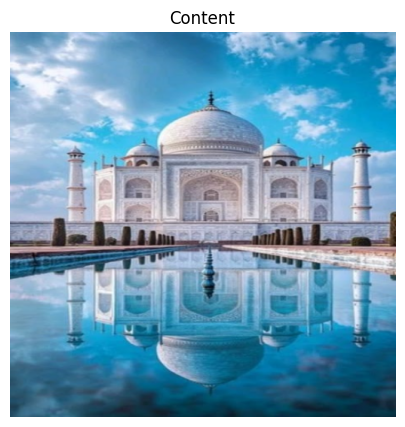

In [67]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
imshow(content,'Content')
plt.show()

## 🎨 Style Image

The style image contributes:

✨ Colors

✨ Textures

✨ Artistic Patterns

✨ Visual Mood

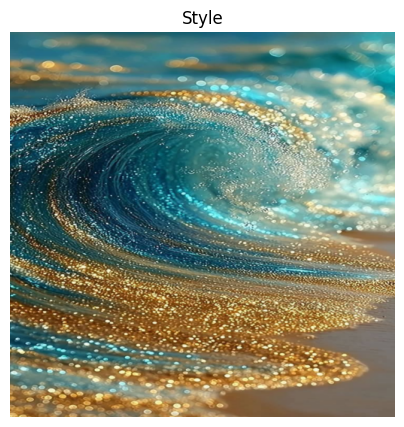

In [68]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
imshow(style,'Style')
plt.show()

In [45]:
normalize=transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)


In [46]:
content=normalize(content.squeeze(0)).unsqueeze(0)
style=normalize(style.squeeze(0)).unsqueeze(0)

## Why VGG19?

VGG19 is pretrained on ImageNet and contains hierarchical feature representations.

Early layers capture:
- Edges
- Colors
- Textures

Deeper layers capture:
- Shapes
- Structures
- Semantic information

These representations make VGG19 ideal for Neural Style Transfer.

In [47]:
vgg=models.vgg19(weights='DEFAULT').features
vgg=vgg.to(device)

In [48]:
for param in vgg.parameters():
    param.require_grads=False

## Feature Extraction

Instead of using the final output of VGG19, intermediate activations are extracted.

Content Representation:
- conv4_2

Style Representation:
- conv1_1
- conv2_1
- conv3_1
- conv4_1
- conv5_1

In [49]:
layers = {
    '0': 'conv1_1',
    '5': 'conv2_1',
    '10': 'conv3_1',
    '19': 'conv4_1',
    '21': 'conv4_2',
    '28': 'conv5_1'
}

In [50]:
def get_features(image,model):
    features={}
    x=image
    for name,layer in model._modules.items():
        x=layer(x)
        if name in layers:
            features[layers[name]]=x
    return features

In [51]:
with torch.no_grad():

    content_features = get_features(
        content,
        vgg
    )

    style_features = get_features(
        style,
        vgg
    )

## Gram Matrix

A Gram Matrix measures correlations between feature maps.

Rather than preserving exact pixel locations, it captures textures and patterns present in an image.

This allows style information to be represented independently of spatial arrangement.

In [52]:
def gram_matrix(tensor):
    _,c,h,w=tensor.shape
    tensor=tensor.view(c,h*w)
    gram=torch.mm(tensor,tensor.t())
    return gram

In [53]:
style_grams = {}

for layer in style_features:

    style_grams[layer] = gram_matrix(
        style_features[layer]
    ).detach()

In [54]:
generated = content.clone().requires_grad_(True)

In [55]:
optimizer = torch.optim.Adam(
    [generated],
    lr=0.01
)

In [56]:
style_weights = {
    'conv1_1': 1.0,
    'conv2_1': 0.75,
    'conv3_1': 0.2,
    'conv4_1': 0.2,
    'conv5_1': 0.2
}

In [57]:
content_weight = 1
style_weight = 1e4

In [58]:
steps=2000

In [59]:
print(content_features['conv4_2'].requires_grad)

print(style_grams['conv1_1'].requires_grad)



False
False


## Content Loss

Measures how closely the generated image preserves the structure of the content image.

## Style Loss

Measures similarity between Gram Matrices of the generated and style images.

## Total Loss

Total Loss =
Content Weight × Content Loss
+
Style Weight × Style Loss

In [60]:
for step in range(steps):

    generated_features = get_features(
        generated,
        vgg
    )

    content_loss = torch.mean(
        (
            generated_features['conv4_2']
            -
            content_features['conv4_2']
        ) ** 2
    )

    style_loss = 0

    for layer in style_weights:

        generated_feature = generated_features[layer]

        generated_gram = gram_matrix(
            generated_feature
        )

        style_gram = style_grams[layer]

        layer_style_loss = torch.mean(
            (
                generated_gram
                -
                style_gram
            ) ** 2
        )

        style_loss += (
            style_weights[layer]
            *
            layer_style_loss
        )

    total_loss = (
        content_weight * content_loss
        +
        style_weight * style_loss
    )

    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()
    if step % 100 == 0:
        print(f"step : {step}  Total_loss : {total_loss.item()}" )

step : 0  Total_loss : 92982166421504.0
step : 100  Total_loss : 2788614209536.0
step : 200  Total_loss : 1190958465024.0
step : 300  Total_loss : 740529274880.0
step : 400  Total_loss : 491019993088.0
step : 500  Total_loss : 341525954560.0
step : 600  Total_loss : 249244745728.0
step : 700  Total_loss : 189743054848.0
step : 800  Total_loss : 149438234624.0
step : 900  Total_loss : 120813830144.0
step : 1000  Total_loss : 99616956416.0
step : 1100  Total_loss : 83426770944.0
step : 1200  Total_loss : 70768508928.0
step : 1300  Total_loss : 60672409600.0
step : 1400  Total_loss : 52464087040.0
step : 1500  Total_loss : 45718319104.0
step : 1600  Total_loss : 40117633024.0
step : 1700  Total_loss : 35427643392.0
step : 1800  Total_loss : 31463530496.0
step : 1900  Total_loss : 28089210880.0


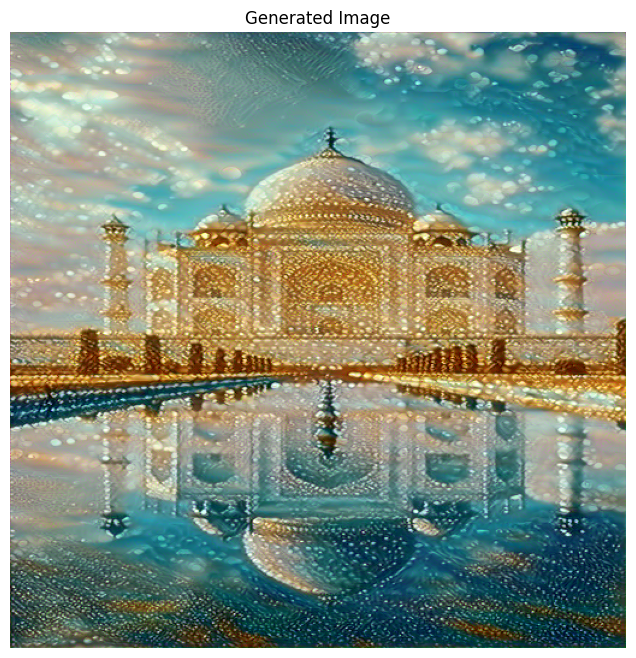

In [61]:
# Denormalize image

def denormalize(tensor):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(1,3,1,1).to(tensor.device)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(1,3,1,1).to(tensor.device)

    return tensor * std + mean


# Prepare image for display

result = denormalize(
    generated.detach()
)

result = torch.clamp(
    result,
    0,
    1
)

# Convert to matplotlib format

image = result.squeeze(0)
image = image.cpu().permute(1,2,0)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Image")
plt.show()

# ✨ Results

The generated image successfully combines:

✅ Structural integrity of the Taj Mahal

✅ Color palette from the style image

✅ Artistic texture transfer

✅ Reflection preservation

# 🔍 Observations

1. The Taj Mahal remains clearly recognizable.

2. Golden highlights from the style image were transferred effectively.

3. The generated image exhibits strong texture transfer while preserving major architectural elements.

4. Neural Style Transfer demonstrates that deep CNN features can separate content and style representations.

# 🚀 Future Improvements

- Experiment with multiple artistic styles
- Compare style weights systematically
- Use higher resolution images
- Implement Fast Neural Style Transfer
- Build a real-time style transfer application